# Kalshi Trade Preprocessing

Pipeline:

1. Load and filter raw trades, compute volume.
2. Compute forward returns at multiple horizons (regression targets).
3. Temporal 80/20 train/test split.
4. Derive directional jump thresholds from train; apply 3-class labels.
5. Encode tickers via SentenceTransformer + UMAP.
6. Compute per-trade dynamic features (vectorized) including backward returns and jump-streak features.
7. Save to parquet.


## 0. Setup

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

# Mount Drive (Colab only)
try:
    import google.colab
    google.colab.drive.mount('/content/drive')
except ImportError:
    pass

DATA_ROOT = '/content/drive/MyDrive/CS1090B/project/data'

# ---- Config ---------------------------------------------------
HORIZONS_MIN  = [5, 15, 30, 60]
TRAIN_FRAC    = 0.8
JUMP_TOP_PCT  = 25.0          # top X% of positive returns -> up-jump
DATE_CUTOFF   = '2025-01-01'  # filter out earlier sparse data
RECENT_JUMPS_K = 10           # window for "recent jumps" feature


Mounted at /content/drive


## 1. Load, filter, compute volume

In [2]:
all_trades = pd.read_parquet(os.path.join(DATA_ROOT, 'all_trades.parquet'))

all_trades['created_time'] = pd.to_datetime(all_trades['created_time'], utc=True)

# Filter to the dense post-2025 window
cutoff = pd.Timestamp(DATE_CUTOFF, tz='UTC')
all_trades = (all_trades[all_trades['created_time'] >= cutoff]
              .sort_values(['ticker', 'created_time'], kind='stable')
              .reset_index(drop=True))

# Taker-side dollar volume in cents
all_trades['volume'] = np.where(
    all_trades['taker_side'] == 'yes',
    all_trades['yes_price'] * all_trades['count'],
    all_trades['no_price']  * all_trades['count'],
).astype(np.float32)
all_trades['log_volume'] = np.log1p(all_trades['volume']).astype(np.float32)

print(f'Trades after {DATE_CUTOFF} filter : {len(all_trades):,}')
print(f'Date range  : {all_trades["created_time"].min()}  ->  {all_trades["created_time"].max()}')
print(f'Tickers     : {all_trades["ticker"].nunique():,}')
print(f'Median vol  : {all_trades["volume"].median():,.0f} cents')
all_trades.head()


Trades after 2025-01-01 filter : 63,801,798
Date range  : 2025-01-01 00:00:09.673219+00:00  ->  2025-11-25 22:00:15.194245+00:00
Tickers     : 517,520
Median vol  : 1,290 cents


,ticker,yes_price,no_price,count,taker_side,created_time,volume,log_volume
0,538APPROVEY-24DEC31-T37.9,1,99,304,yes,2025-01-01 02:57:15.947080+00:00,304.0,5.720312
1,ACPI-24-B1.5,1,99,38,yes,2025-01-01 15:09:30.590342+00:00,38.0,3.663562
2,ACPI-24-B1.5,1,99,12,yes,2025-01-01 15:09:30.590342+00:00,12.0,2.564949
3,ACPI-24-B1.5,2,98,42,yes,2025-01-01 15:23:33.219179+00:00,84.0,4.442651
4,ACPI-24-B1.5,1,99,850,yes,2025-01-01 15:23:33.219179+00:00,850.0,6.746412


## 2. Forward returns (regression targets)

For each trade $t$ on ticker $T$, find the most recent trade $t^\star$ on the
same ticker with $\tau_{t^\star} \le \tau_t + h$ minutes. The signed forward
return is $\Delta p^{(h)}_t = p_{t^\star} - p_t$. If no successor exists in
$(\tau_t, \tau_t + h]$, the matched trade is the trade itself and the return
is zero.

Implementation uses per-ticker `searchsorted`, which is bounded to the ticker
slice and therefore cannot leak across markets.


In [3]:
times_ns = all_trades['created_time'].astype(np.int64).values
prices   = all_trades['yes_price'].values.astype(np.float32)
n        = len(all_trades)

# Ticker boundaries — data is already sorted by ticker
ticker_codes  = pd.factorize(all_trades['ticker'])[0]
change_points = np.where(np.diff(ticker_codes) != 0)[0] + 1
starts        = np.concatenate([[0], change_points])
ends          = np.concatenate([change_points, [n]])
print(f'Tickers: {len(starts):,}   Trades: {n:,}')

def forward_returns(times_ns, prices, starts, ends, delta_ns):
    """For each i: find largest j (per-ticker) with times[j] <= times[i] + delta_ns."""
    n = len(prices)
    future_price = np.empty(n, dtype=np.float32)
    for s, e in zip(starts, ends):
        t_grp = times_ns[s:e]
        p_grp = prices[s:e]
        target = t_grp + delta_ns
        j      = np.searchsorted(t_grp, target, side='right') - 1
        future_price[s:e] = p_grp[j]
    return future_price

for h in tqdm(HORIZONS_MIN, desc='Forward returns'):
    delta_ns = int(h * 60 * 1e9)
    fp       = forward_returns(times_ns, prices, starts, ends, delta_ns)
    signed   = (fp - prices).astype(np.float32)
    all_trades[f'target_price_{h}m'] = fp
    all_trades[f'signed_ret_{h}m']   = signed
    all_trades[f'abs_ret_{h}m']      = np.abs(signed)


Tickers: 517,520   Trades: 63,801,798


Forward returns:   0%|          | 0/4 [00:00<?, ?it/s]

## 3. Temporal 80/20 split

In [4]:
split_time = all_trades['created_time'].quantile(TRAIN_FRAC)
all_trades['split'] = np.where(all_trades['created_time'] < split_time,
                               'train', 'test')
train_mask = all_trades['split'] == 'train'

print(f'Split time : {split_time}')
print(f'Train      : {train_mask.sum():,} rows')
print(f'Test       : {(~train_mask).sum():,} rows')


Split time : 2025-11-06 03:58:08.019598080+00:00
Train      : 51,041,438 rows
Test       : 12,760,360 rows


## 4. Jump thresholds and 3-class labels

For each horizon, we compute:
- `up_thr`   = top $\alpha$ quantile of *positive* training returns
- `down_thr` = bottom $\alpha$ quantile of *negative* training returns

We label each trade as $+1$ (up-jump), $-1$ (down-jump), or $0$ (no jump).
Conditioning on sign before quantiling is necessary because the spike at
$\Delta p = 0$ would otherwise dominate.


In [5]:
thresholds = {}    # {h: (down_thr, up_thr)}

print(f'Thresholds (top/bottom {JUMP_TOP_PCT}% of conditional signed returns):')
for h in tqdm(HORIZONS_MIN, desc='Thresholds'):
    signed = all_trades.loc[train_mask, f'signed_ret_{h}m'].dropna()
    pos = signed[signed > 0]
    neg = signed[signed < 0]
    up_thr   = np.quantile(pos, 1 - JUMP_TOP_PCT / 100) if len(pos) else np.nan
    down_thr = np.quantile(neg,     JUMP_TOP_PCT / 100) if len(neg) else np.nan
    thresholds[h] = (down_thr, up_thr)
    tqdm.write(f'  {h:>2}m  |  down_thr = {down_thr:+.2f}c  |  up_thr = +{up_thr:.2f}c'
               f'  |  pos = {len(pos):,}  neg = {len(neg):,}  zero = {(signed == 0).sum():,}')

# Apply thresholds -> 3-class labels (-1 / 0 / +1)
print('\n3-class label distributions:')
for h in tqdm(HORIZONS_MIN, desc='Labeling jumps'):
    signed_ret       = all_trades[f'signed_ret_{h}m'].values
    down_thr, up_thr = thresholds[h]
    jump3 = np.zeros(n, dtype=np.float32)
    jump3[signed_ret >= up_thr]   =  1.0
    jump3[signed_ret <= down_thr] = -1.0
    all_trades[f'jump3_{h}m'] = jump3

    train_dist = all_trades.loc[ train_mask, f'jump3_{h}m'].value_counts(normalize=True).sort_index()
    test_dist  = all_trades.loc[~train_mask, f'jump3_{h}m'].value_counts(normalize=True).sort_index()
    fmt = lambda d: ' / '.join([f'{int(k):+d}: {v:.2%}' for k, v in d.items()])
    tqdm.write(f'  {h:>2}m  |  down <= {down_thr:+.0f}c  |  up >= +{up_thr:.0f}c')
    tqdm.write(f'        train  ({fmt(train_dist)})')
    tqdm.write(f'        test   ({fmt(test_dist)})')


Thresholds (top/bottom 25.0% of conditional signed returns):


Thresholds:   0%|          | 0/4 [00:00<?, ?it/s]

   5m  |  down_thr = -10.00c  |  up_thr = +10.00c  |  pos = 16,684,340  neg = 16,345,561  zero = 18,011,537
  15m  |  down_thr = -16.00c  |  up_thr = +16.00c  |  pos = 18,122,590  neg = 18,278,360  zero = 14,640,488
  30m  |  down_thr = -21.00c  |  up_thr = +22.00c  |  pos = 18,953,648  neg = 19,531,258  zero = 12,556,532
  60m  |  down_thr = -28.00c  |  up_thr = +31.00c  |  pos = 19,656,808  neg = 20,765,394  zero = 10,619,236

3-class label distributions:


Labeling jumps:   0%|          | 0/4 [00:00<?, ?it/s]

   5m  |  down <= -10c  |  up >= +10c
        train  (-1: 8.33% / +0: 83.28% / +1: 8.39%)
        test   (-1: 9.17% / +0: 81.69% / +1: 9.15%)
  15m  |  down <= -16c  |  up >= +16c
        train  (-1: 9.29% / +0: 81.37% / +1: 9.34%)
        test   (-1: 10.16% / +0: 79.79% / +1: 10.04%)
  30m  |  down <= -21c  |  up >= +22c
        train  (-1: 10.07% / +0: 80.31% / +1: 9.63%)
        test   (-1: 11.16% / +0: 78.29% / +1: 10.55%)
  60m  |  down <= -28c  |  up >= +31c
        train  (-1: 10.59% / +0: 79.77% / +1: 9.64%)
        test   (-1: 11.83% / +0: 77.57% / +1: 10.60%)


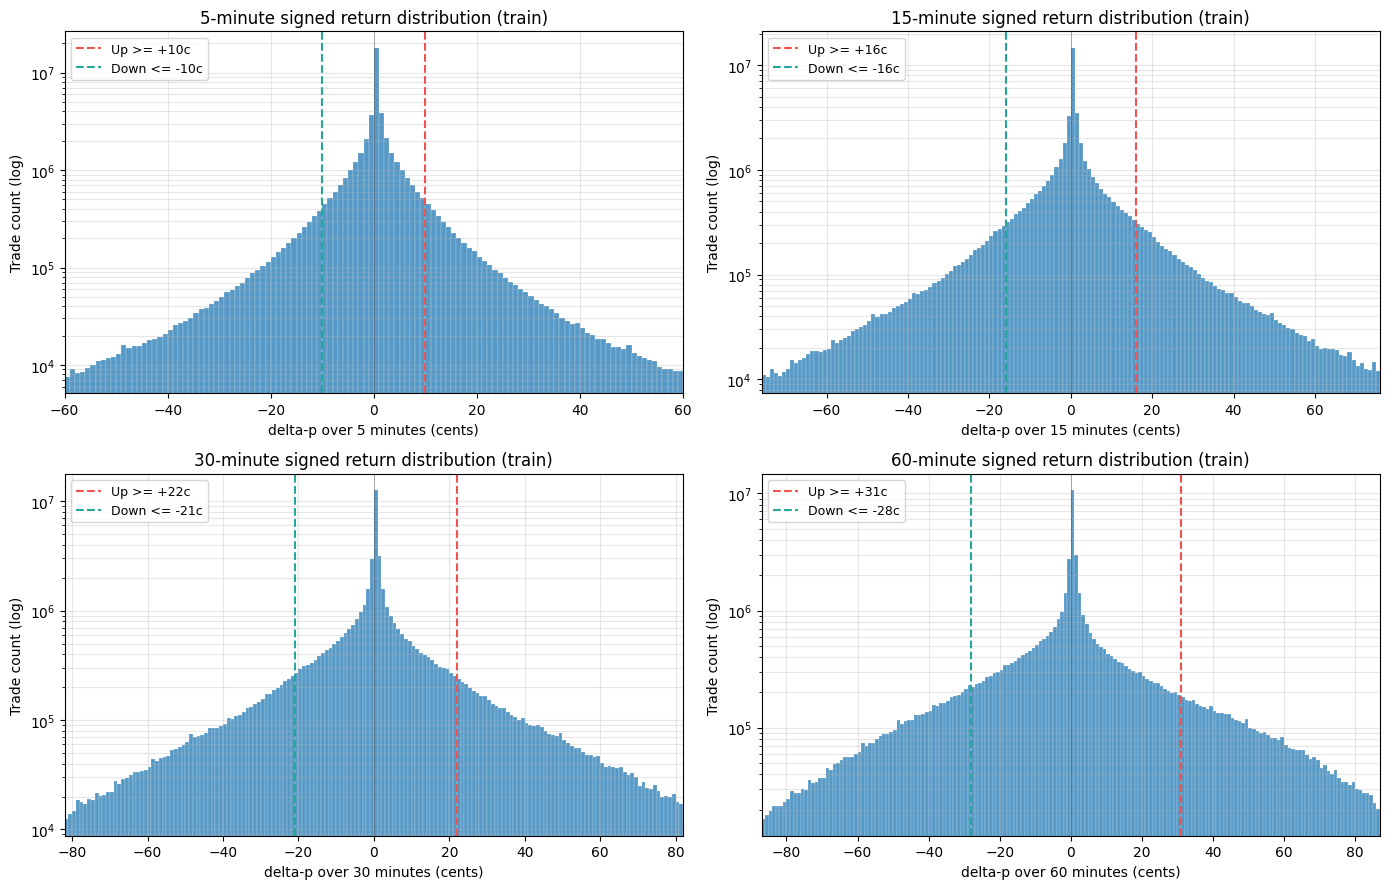

In [6]:
# ---- Plot signed-return distributions with thresholds -------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, h in zip(axes.flatten(), HORIZONS_MIN):
    train_ret        = all_trades.loc[train_mask, f'signed_ret_{h}m'].dropna()
    down_thr, up_thr = thresholds[h]
    x_max = int(train_ret.abs().quantile(0.995))
    bins  = np.arange(-x_max - 1, x_max + 2)

    ax.hist(train_ret[train_ret.between(-x_max, x_max)], bins=bins,
            color='#1f77b4', alpha=0.75, edgecolor='white', linewidth=0.2)
    ax.axvline(up_thr,   color='#ef5350', linestyle='--', linewidth=1.5,
               label=f'Up >= +{up_thr:.0f}c')
    ax.axvline(down_thr, color='#26a69a', linestyle='--', linewidth=1.5,
               label=f'Down <= {down_thr:.0f}c')
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_yscale('log')
    ax.set_xlim(-x_max, x_max)
    ax.set_xlabel(f'delta-p over {h} minutes (cents)')
    ax.set_ylabel('Trade count (log)')
    ax.set_title(f'{h}-minute signed return distribution (train)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()


In [7]:
# ---- Sanity check ----------------------------------------------
sub = all_trades[all_trades['ticker'] == 'PRES-2024-DJT'].sort_values('created_time').reset_index(drop=True)
if len(sub) > 1000:
    print('PRES-2024-DJT trade #1000:')
    print(sub.iloc[1000][['created_time', 'yes_price', 'target_price_5m',
                          'signed_ret_5m', 'abs_ret_5m', 'jump3_5m']])


PRES-2024-DJT trade #1000:
created_time       2025-01-10 01:46:30.806198+00:00
yes_price                                        99
target_price_5m                                99.0
signed_ret_5m                                   0.0
abs_ret_5m                                      0.0
jump3_5m                                        0.0
Name: 1000, dtype: object


## 5. Ticker semantic embeddings

`all-MiniLM-L6-v2` on humanized ticker strings, then UMAP to 8D for model
features and 2D for visualization.


Device: cuda GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
cuML detected -> UMAP on GPU
Unique tickers : 517,520


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Humanizing:   0%|          | 0/517520 [00:00<?, ?it/s]

Batches:   0%|          | 0/127 [00:00<?, ?it/s]

Raw SBERT embeddings: (517520, 384)
UMAP 2D...
[2026-05-09 13:55:55.733] [CUML] [debug] Computing KNN Graph
[2026-05-09 13:56:01.797] [CUML] [debug] Computing fuzzy simplicial set
UMAP 8D...
[2026-05-09 13:56:05.352] [CUML] [debug] Building knn graph using build_algo='brute_force_knn'
[2026-05-09 13:56:05.389] [CUML] [debug] Computing KNN Graph
[2026-05-09 13:56:11.370] [CUML] [debug] Computing fuzzy simplicial set


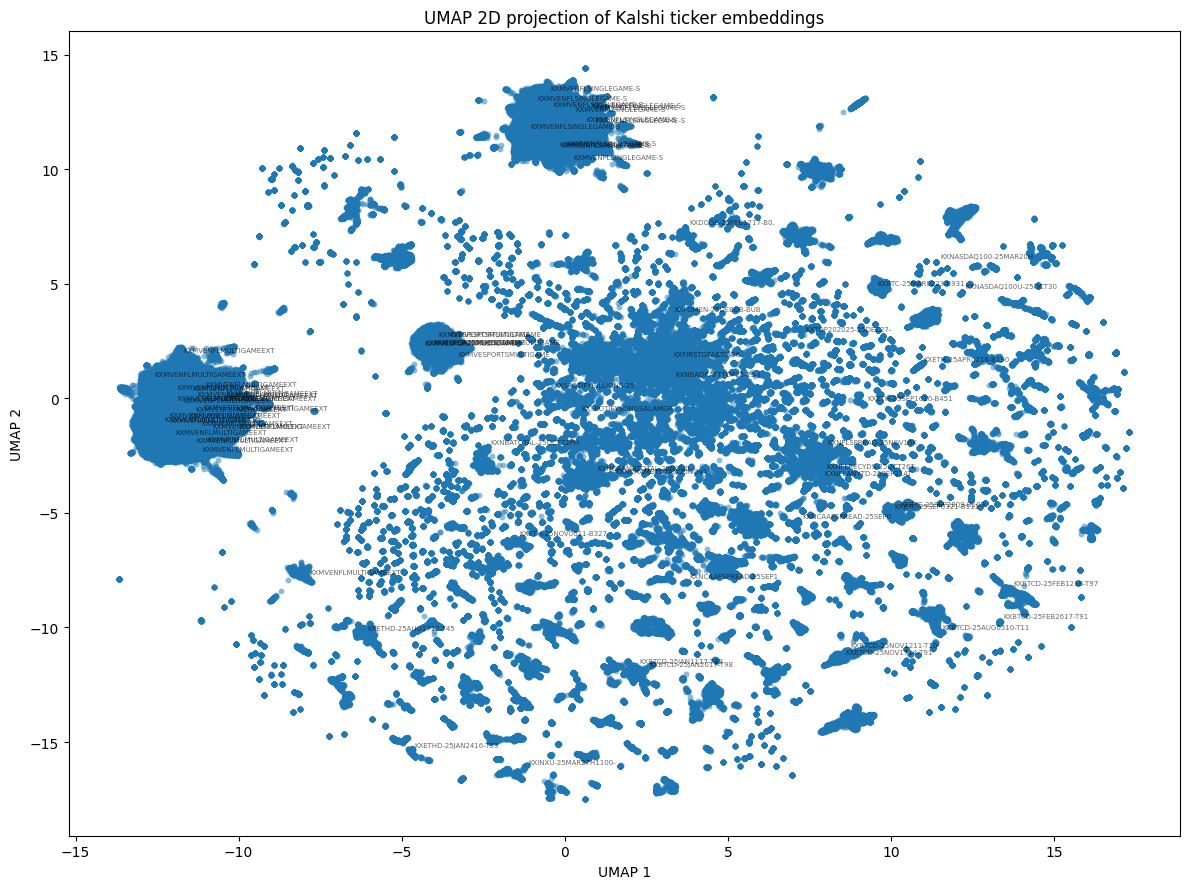

Embeddings joined. NaN check: 0


In [8]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}', f'GPU: {torch.cuda.get_device_name(0)}' if DEVICE == 'cuda' else '')

try:
    from cuml.manifold import UMAP as cuUMAP
    HAS_CUML = True
    print('cuML detected -> UMAP on GPU')
except ImportError:
    import umap
    HAS_CUML = False
    print('cuML missing -> UMAP on CPU')

# ---- Encode ticker strings -------------------------------------
tickers = all_trades['ticker'].unique().tolist()
print(f'Unique tickers : {len(tickers):,}')

humanize = lambda t: re.sub(r'[-_]', ' ', t)

encoder = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
if DEVICE == 'cuda':
    encoder = encoder.half()

texts = [humanize(t) for t in tqdm(tickers, desc='Humanizing')]
batch = 4096 if DEVICE == 'cuda' else 128
raw_embs = encoder.encode(texts, batch_size=batch, show_progress_bar=True,
                          convert_to_numpy=True, normalize_embeddings=True
                          ).astype(np.float32)
print(f'Raw SBERT embeddings: {raw_embs.shape}')

# ---- UMAP ------------------------------------------------------
def fit_umap(X, n_components, min_dist, n_neighbors=15, seed=42):
    n_neighbors = min(n_neighbors, len(X) - 1)
    cls = cuUMAP if HAS_CUML else umap.UMAP
    kw = dict(n_components=n_components, n_neighbors=n_neighbors,
              min_dist=min_dist, metric='cosine', random_state=seed, verbose=True)
    if not HAS_CUML:
        kw['n_jobs'] = -1
    return np.asarray(cls(**kw).fit_transform(X))

print('UMAP 2D...')
emb_2d = fit_umap(raw_embs, n_components=2, min_dist=0.1)
print('UMAP 8D...')
emb_8d = fit_umap(raw_embs, n_components=8, min_dist=0.05)

# ---- 2D plot ---------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(emb_2d[:, 0], emb_2d[:, 1], s=18, alpha=0.5, linewidths=0, c='#1f77b4')
rng = np.random.default_rng(42)
for i in rng.choice(len(tickers), size=min(80, len(tickers)), replace=False):
    ax.annotate(tickers[i][:20], (emb_2d[i, 0], emb_2d[i, 1]),
                fontsize=5, alpha=0.6, xytext=(3, 3), textcoords='offset points')
ax.set_title('UMAP 2D projection of Kalshi ticker embeddings')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.tight_layout(); plt.show()

# ---- Join 8D embeddings onto trades ----------------------------
EMB_COLS = [f'ticker_emb_{i}' for i in range(8)]
ticker_emb_df = pd.DataFrame(emb_8d.astype(np.float32), index=tickers, columns=EMB_COLS)
ticker_emb_df.index.name = 'ticker'
all_trades = all_trades.drop(columns=EMB_COLS, errors='ignore')
all_trades = all_trades.join(ticker_emb_df, on='ticker')
print(f'Embeddings joined. NaN check: {all_trades[EMB_COLS].isna().sum().sum()}')


## 6. Per-trade dynamic features

All features are causal — they depend only on data up to and including the
current trade. Vectorized using pandas groupby + rolling.

**Existing features:**
- `log_time_delta` — log seconds since previous trade on this ticker
- `ret_last_k` for $k \in \{5, 10, 20\}$ — momentum over last $k$ trades
- `position_in_range` — current price relative to last-20-trade [low, high]
- `dist_from_50` — $|p - 50| / 50$
- `relative_volume` — volume vs rolling-20 mean
- `tick`, `run_length` — direction and persistence of last move
- `volume_since_price_change` — log(1 + cumulative volume since last tick)
- `trades_last_60s`, `trades_last_300s` — time-windowed trade counts
- `hour_sin`, `hour_cos` — cyclical hour-of-day

**New features:**
- `backward_ret_{h}m` for $h \in \{5, 15, 30, 60\}$ — signed return over the past $h$ minutes
- `backward_abs_ret_{h}m` — corresponding magnitude (recent realized volatility)
- `recent_up_jumps_{h}m`, `recent_down_jumps_{h}m` — count of same-direction backward jumps in the previous `RECENT_JUMPS_K` trades, using train thresholds


In [9]:
# ---- 6a. Backward returns at horizons --------------------------
# Mirror of the forward computation: for each trade i, find the most recent
# trade j (per-ticker) with times[j] <= times[i] - delta_ns.
def backward_returns(times_ns, prices, starts, ends, delta_ns):
    n = len(prices)
    past_price = np.empty(n, dtype=np.float32)
    for s, e in zip(starts, ends):
        t_grp = times_ns[s:e]
        p_grp = prices[s:e]
        target = t_grp - delta_ns
        # rightmost j with t_grp[j] <= target
        j = np.searchsorted(t_grp, target, side='right') - 1
        # When j < 0 (no past trade within window) we fall back to current price -> 0 return
        valid = j >= 0
        out = p_grp.copy()           # default = current price
        out[valid] = p_grp[j[valid]]
        past_price[s:e] = out
    return past_price

for h in tqdm(HORIZONS_MIN, desc='Backward returns'):
    delta_ns = int(h * 60 * 1e9)
    pp       = backward_returns(times_ns, prices, starts, ends, delta_ns)
    signed   = (prices - pp).astype(np.float32)
    all_trades[f'backward_ret_{h}m']     = signed
    all_trades[f'backward_abs_ret_{h}m'] = np.abs(signed)


Backward returns:   0%|          | 0/4 [00:00<?, ?it/s]

In [10]:
# ---- 6b. Recent jump counts (time-windowed, strictly past) ----
# At each trade i, count same-direction backward jumps within the past WINDOW
# minutes on the same ticker. Time-based so the feature has consistent meaning
# regardless of market activity level.
WINDOW = '30min'
print(f'Computing recent jump counts (time window = {WINDOW})...')

# Build a single time-indexed Series we can roll on, with ticker as a separate column for groupby
tmp = all_trades[['ticker', 'created_time']].copy()
tmp = tmp.set_index('created_time')

for h in tqdm(HORIZONS_MIN, desc='Recent jumps'):
    down_thr, up_thr = thresholds[h]
    bret = all_trades[f'backward_ret_{h}m'].values

    tmp['is_up']   = (bret >= up_thr).astype(np.float32)
    tmp['is_down'] = (bret <= down_thr).astype(np.float32)

    up_count = (tmp.groupby('ticker', sort=False)['is_up']
                   .rolling(WINDOW, closed='left').sum()
                   .reset_index(level=0, drop=True))
    down_count = (tmp.groupby('ticker', sort=False)['is_down']
                     .rolling(WINDOW, closed='left').sum()
                     .reset_index(level=0, drop=True))

    all_trades[f'recent_up_jumps_{h}m']   = up_count.values.astype(np.float32)
    all_trades[f'recent_down_jumps_{h}m'] = down_count.values.astype(np.float32)

# Fill NaNs (first trade in each ticker has no prior window)
for col in [c for c in all_trades.columns if c.startswith('recent_')]:
    all_trades[col] = all_trades[col].fillna(0)

Computing recent jump counts (time window = 30min)...


Recent jumps:   0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
# ---- 6c. Existing dynamic features (vectorized) ----------------
# Use groupby + shift/rolling rather than per-ticker Python loops.

g = all_trades.groupby('ticker', sort=False)

# log_time_delta
dt_sec = g['created_time'].diff().dt.total_seconds().clip(lower=0).fillna(0)
all_trades['log_time_delta'] = np.log1p(dt_sec).astype(np.float32)

# ret_last_k (simple percentage returns)
for k in [5, 10, 20]:
    prev = g['yes_price'].shift(k)
    all_trades[f'ret_last_{k}'] = ((all_trades['yes_price'] - prev)).astype(np.float32)

# position_in_range over previous 20 trades
shifted_p = g['yes_price'].shift(1)
roll_min  = shifted_p.groupby(all_trades['ticker'], sort=False).transform(lambda s: s.rolling(20, min_periods=1).min())
roll_max  = shifted_p.groupby(all_trades['ticker'], sort=False).transform(lambda s: s.rolling(20, min_periods=1).max())
denom     = (roll_max - roll_min).replace(0, np.nan)
all_trades['position_in_range'] = ((all_trades['yes_price'] - roll_min) / denom).astype(np.float32)

# dist_from_50
all_trades['dist_from_50'] = (np.abs(all_trades['yes_price'] - 50) / 50).astype(np.float32)

# relative_volume vs rolling-20 mean of past volumes
shifted_v = g['volume'].shift(1)
roll_mean = shifted_v.groupby(all_trades['ticker'], sort=False).transform(lambda s: s.rolling(20, min_periods=1).mean())
all_trades['relative_volume'] = (all_trades['volume'] / roll_mean.replace(0, np.nan)).astype(np.float32)

# tick (sign of last price move within ticker)
price_diff = g['yes_price'].diff().fillna(0)
all_trades['tick'] = np.sign(price_diff).astype(np.float32)


In [12]:
# ---- 6d. Stateful features: run_length and volume_since_price_change ----
# run_length: consecutive trades in the same nonzero tick direction.
# We use the cumcount-on-reset trick: a new "group" begins whenever tick changes.
print('Stateful features (run_length, volume_since_price_change)...')

tick = all_trades['tick'].values
volume = all_trades['volume'].values.astype(np.float64)
ticker_codes = pd.factorize(all_trades['ticker'])[0]

# Group identifier increments whenever tick changes within a ticker
ticker_change = np.concatenate([[True], np.diff(ticker_codes) != 0])
tick_change   = np.concatenate([[True], np.diff(tick) != 0])
group_break   = ticker_change | tick_change
group_id      = group_break.cumsum() - 1

# run_length = within-group cumulative count, set to 0 where tick == 0
run_length = pd.Series(np.ones(len(tick), dtype=np.int64)).groupby(group_id).cumsum().values
run_length[tick == 0] = 0
all_trades['run_length'] = run_length.astype(np.float32)

# volume_since_price_change: cumulative volume since the last nonzero tick on this ticker.
# Reset at each ticker boundary AND each nonzero tick.
reset = ticker_change | (tick != 0)
group_id_v = reset.cumsum() - 1
cumvol = pd.Series(volume).groupby(group_id_v).cumsum().values
all_trades['volume_since_price_change'] = np.log1p(cumvol).astype(np.float32)


Stateful features (run_length, volume_since_price_change)...


In [13]:
# ---- 6e. Time-windowed trade counts ----------------------------
# trades_last_60s / 300s: number of trades in the last X seconds on this ticker.
print('Time-windowed counts (60s, 300s)...')
ts_indexed = all_trades.set_index('created_time')

for window in ['60s', '300s']:
    counts = (ts_indexed.groupby('ticker', sort=False)['yes_price']
              .rolling(window, closed='left')   # closed='left' excludes current trade
              .count()
              .reset_index(level=0, drop=True))
    all_trades[f'trades_last_{window}'] = counts.values.astype(np.float32)

all_trades['trades_last_60s']  = all_trades['trades_last_60s'].fillna(0)
all_trades['trades_last_300s'] = all_trades['trades_last_300s'].fillna(0)


Time-windowed counts (60s, 300s)...


In [14]:
# ---- 6f. Hour-of-day cyclical encoding -------------------------
hour = all_trades['created_time'].dt.hour + all_trades['created_time'].dt.minute / 60.0
all_trades['hour_sin'] = np.sin(2 * np.pi * hour / 24.0).astype(np.float32)
all_trades['hour_cos'] = np.cos(2 * np.pi * hour / 24.0).astype(np.float32)

# ---- Final feature column list ---------------------------------
FEATURE_COLS = (
    ['yes_price', 'log_volume', 'log_time_delta',
     'ret_last_5', 'ret_last_10', 'ret_last_20',
     'position_in_range', 'dist_from_50',
     'relative_volume', 'tick', 'run_length',
     'volume_since_price_change',
     'trades_last_60s', 'trades_last_300s',
     'hour_sin', 'hour_cos']
    + [f'backward_ret_{h}m'     for h in HORIZONS_MIN]
    + [f'backward_abs_ret_{h}m' for h in HORIZONS_MIN]
    + [f'recent_up_jumps_{h}m'  for h in HORIZONS_MIN]
    + [f'recent_down_jumps_{h}m' for h in HORIZONS_MIN]
    + EMB_COLS
)

print(f'Total trades            : {len(all_trades):,}')
print(f'Feature columns ({len(FEATURE_COLS)}) :')
for c in FEATURE_COLS:
    print(f'  {c}')

print('\nNaN counts (top 10):')
nan_counts = all_trades[FEATURE_COLS].isna().sum().sort_values(ascending=False)
print(nan_counts.head(10).to_string())

all_trades[['ticker', 'created_time'] + FEATURE_COLS].head(10)


Total trades            : 63,801,798
Feature columns (40) :
  yes_price
  log_volume
  log_time_delta
  ret_last_5
  ret_last_10
  ret_last_20
  position_in_range
  dist_from_50
  relative_volume
  tick
  run_length
  volume_since_price_change
  trades_last_60s
  trades_last_300s
  hour_sin
  hour_cos
  backward_ret_5m
  backward_ret_15m
  backward_ret_30m
  backward_ret_60m
  backward_abs_ret_5m
  backward_abs_ret_15m
  backward_abs_ret_30m
  backward_abs_ret_60m
  recent_up_jumps_5m
  recent_up_jumps_15m
  recent_up_jumps_30m
  recent_up_jumps_60m
  recent_down_jumps_5m
  recent_down_jumps_15m
  recent_down_jumps_30m
  recent_down_jumps_60m
  ticker_emb_0
  ticker_emb_1
  ticker_emb_2
  ticker_emb_3
  ticker_emb_4
  ticker_emb_5
  ticker_emb_6
  ticker_emb_7

NaN counts (top 10):
position_in_range    6346469
ret_last_20          4109982
ret_last_10          2545664
ret_last_5           1552454
relative_volume       523692
log_time_delta             0
yes_price                  0
log_

,ticker,created_time,yes_price,log_volume,log_time_delta,ret_last_5,ret_last_10,ret_last_20,position_in_range,dist_from_50,...,recent_down_jumps_30m,recent_down_jumps_60m,ticker_emb_0,ticker_emb_1,ticker_emb_2,ticker_emb_3,ticker_emb_4,ticker_emb_5,ticker_emb_6,ticker_emb_7
0,538APPROVEY-24DEC31-T37.9,2025-01-01 02:57:15.947080+00:00,1,5.720312,0.000000,NaN,NaN,NaN,NaN,0.98,...,0.0,0.0,1.153557,-0.613788,-0.914040,-4.345767,-0.960846,7.964265,2.691060,-2.249062
1,ACPI-24-B1.5,2025-01-01 15:09:30.590342+00:00,1,3.663562,0.000000,NaN,NaN,NaN,NaN,0.98,...,0.0,0.0,8.324194,-1.567758,2.414129,0.528984,-0.290241,1.881847,2.794698,-1.522861
2,ACPI-24-B1.5,2025-01-01 15:09:30.590342+00:00,1,2.564949,0.000000,NaN,NaN,NaN,NaN,0.98,...,0.0,0.0,8.324194,-1.567758,2.414129,0.528984,-0.290241,1.881847,2.794698,-1.522861
3,ACPI-24-B1.5,2025-01-01 15:23:33.219179+00:00,2,4.442651,6.737713,NaN,NaN,NaN,NaN,0.96,...,0.0,0.0,8.324194,-1.567758,2.414129,0.528984,-0.290241,1.881847,2.794698,-1.522861
4,ACPI-24-B1.5,2025-01-01 15:23:33.219179+00:00,1,6.746412,0.000000,NaN,NaN,NaN,0.0,0.98,...,0.0,0.0,8.324194,-1.567758,2.414129,0.528984,-0.290241,1.881847,2.794698,-1.522861
5,ACPI-24-B1.5,2025-01-13 05:06:07.525974+00:00,1,4.615120,13.815266,NaN,NaN,NaN,0.0,0.98,...,0.0,0.0,8.324194,-1.567758,2.414129,0.528984,-0.290241,1.881847,2.794698,-1.522861
6,ACPI-24-B2.5,2025-01-01 00:19:36.724533+00:00,73,8.895766,0.000000,NaN,NaN,NaN,NaN,0.46,...,0.0,0.0,8.330500,-1.555523,2.419568,0.531284,-0.276191,1.879642,2.802069,-1.521082
7,ACPI-24-B2.5,2025-01-01 00:33:49.180654+00:00,73,6.084499,6.749294,NaN,NaN,NaN,NaN,0.46,...,0.0,0.0,8.330500,-1.555523,2.419568,0.531284,-0.276191,1.879642,2.802069,-1.521082
8,ACPI-24-B2.5,2025-01-01 01:36:01.074688+00:00,73,6.594413,8.224939,NaN,NaN,NaN,NaN,0.46,...,0.0,0.0,8.330500,-1.555523,2.419568,0.531284,-0.276191,1.879642,2.802069,-1.521082
9,ACPI-24-B2.5,2025-01-01 02:59:57.806555+00:00,73,6.856462,8.524712,NaN,NaN,NaN,NaN,0.46,...,0.0,0.0,8.330500,-1.555523,2.419568,0.531284,-0.276191,1.879642,2.802069,-1.521082


## 7. Save

In [15]:
import shutil

LOCAL_TMP  = '/content/all_trades_features.parquet'
DRIVE_PATH = os.path.join(DATA_ROOT, 'all_trades_features.parquet')

# Cast all float64 to float32 to halve the file size
float64_cols = all_trades.select_dtypes('float64').columns
all_trades[float64_cols] = all_trades[float64_cols].astype('float32')
all_trades['ticker'] = all_trades['ticker'].astype('category')

print('Writing parquet locally...')
all_trades.to_parquet(LOCAL_TMP, engine='pyarrow', compression='zstd', index=False)
print(f'Local size: {os.path.getsize(LOCAL_TMP) / 1e9:.2f} GB')

print('Copying to Drive...')
shutil.copy(LOCAL_TMP, DRIVE_PATH)
print(f'Saved to {DRIVE_PATH}')


Writing parquet locally...
Local size: 2.69 GB
Copying to Drive...
Saved to /content/drive/MyDrive/CS1090B/project/data/all_trades_features.parquet
